# Adult Income Analysis

## 1. Business Understanding

US census data from 1994. One row represents one person.

| Task | Goal | Learning |
|---|---|---|
| Classification | Predict annual income: `<=50K` or `>50K` dollars | Supervised: income is known |
| Segmentation | Group similar ages, education levels and working hours | Unsupervised: income is excluded |

Compare group profiles and income rates after clustering. Results describe associations, not causes.

Source: [Adult — UCI](https://archive.ics.uci.edu/dataset/2/adult).

## 2. Data Understanding

Inspect the original files before loading. Their contents remain unchanged.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

folder = "/kaggle/input/datasets/aab6ss/adults-dataset/"
sns.set_theme(style="whitegrid", palette="deep")
pd.set_option("display.max_columns", 20)

### Column definitions

In [2]:
with open(folder + "adult.names") as file:
    names_lines = file.read().splitlines()

print("Opening lines")
print("\n".join(names_lines[:5]))
print("\nFeature definitions")
print("\n".join(names_lines[-18:]))

Opening lines
| This data was extracted from the census bureau database found at
| http://www.census.gov/ftp/pub/DES/www/welcome.html
| Donor: Ronny Kohavi and Barry Becker,
|        Data Mining and Visualization
|        Silicon Graphics.

Feature definitions


>50K, <=50K.

age: continuous.
workclass: Private, Self-emp-not-inc, Self-emp-inc, Federal-gov, Local-gov, State-gov, Without-pay, Never-worked.
fnlwgt: continuous.
education: Bachelors, Some-college, 11th, HS-grad, Prof-school, Assoc-acdm, Assoc-voc, 9th, 7th-8th, 12th, Masters, 1st-4th, 10th, Doctorate, 5th-6th, Preschool.
education-num: continuous.
marital-status: Married-civ-spouse, Divorced, Never-married, Separated, Widowed, Married-spouse-absent, Married-AF-spouse.
occupation: Tech-support, Craft-repair, Other-service, Sales, Exec-managerial, Prof-specialty, Handlers-cleaners, Machine-op-inspct, Adm-clerical, Farming-fishing, Transport-moving, Priv-house-serv, Protective-serv, Armed-Forces.
relationship: Wife, Own-child,

| File syntax | Meaning |
|---|---|
| Comment prefix &#124; | Ignore when extracting names |
| `name: values` | Read the name before `:` |
| Definition order | Preserve the original column order |
| Final class column | Append the name `income` |

In [3]:
columns = []
for line in names_lines:
    if ": " in line and not line.startswith("|"):
        columns.append(line.split(":")[0])
columns.append("income")
print(columns)

['age', 'workclass', 'fnlwgt', 'education', 'education-num', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income']


### Training data

In [4]:
with open(folder + "adult.data") as file:
    data_lines = file.read().splitlines()

print("First three records")
print("\n".join(data_lines[:3]))
print("\nRecord with an unknown value")
print(next(line for line in data_lines if "?" in line))

First three records
39, State-gov, 77516, Bachelors, 13, Never-married, Adm-clerical, Not-in-family, White, Male, 2174, 0, 40, United-States, <=50K
50, Self-emp-not-inc, 83311, Bachelors, 13, Married-civ-spouse, Exec-managerial, Husband, White, Male, 0, 0, 13, United-States, <=50K
38, Private, 215646, HS-grad, 9, Divorced, Handlers-cleaners, Not-in-family, White, Male, 0, 0, 40, United-States, <=50K

Record with an unknown value
40, Private, 121772, Assoc-voc, 11, Married-civ-spouse, Craft-repair, Husband, Asian-Pac-Islander, Male, 0, 0, 40, ?, >50K


Comma-separated records, with no header.

| Setting | Purpose |
|---|---|
| `header=None` | Keep the first record |
| `names=columns` | Use the documented names |
| `skipinitialspace=True` | Ignore spaces after commas |
| `na_values="?"` | Recognize unknown values as missing |

In [5]:
train_df = pd.read_csv(folder + "adult.data", header=None, names=columns, skipinitialspace=True, na_values="?")
display(train_df.head())

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


### Test data

In [6]:
with open(folder + "adult.test") as file:
    test_lines = file.read().splitlines()

print("\n".join(test_lines[:4]))

|1x3 Cross validator
25, Private, 226802, 11th, 7, Never-married, Machine-op-inspct, Own-child, Black, Male, 0, 0, 40, United-States, <=50K.
38, Private, 89814, HS-grad, 9, Married-civ-spouse, Farming-fishing, Husband, White, Male, 0, 0, 50, United-States, <=50K.
28, Local-gov, 336951, Assoc-acdm, 12, Married-civ-spouse, Protective-serv, Husband, White, Male, 0, 0, 40, United-States, >50K.


- First line: `|1x3 Cross validator` is metadata → `skiprows=1`.
- Remaining records: same columns as training.

In [7]:
test_df = pd.read_csv(folder + "adult.test", header=None, names=columns, skiprows=1, skipinitialspace=True, na_values="?")
display(test_df.head())

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K.
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K.
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K.
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K.
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,<=50K.


Align test labels: `<=50K.` → `<=50K`, `>50K.` → `>50K`.

In [8]:
#display(test_df["income"].value_counts().to_frame("People"))

### Column meanings

| Column | Meaning |
|---|---|
| `age` | Age in years |
| `workclass` | Employment category |
| `fnlwgt` | Population survey weight |
| `education` | Education level |
| `education-num` | Ordered level code, not years |
| `marital-status` | Marital status |
| `occupation` | Job category |
| `relationship` | Family or household role |
| `race`, `sex` | Categories recorded in the source |
| `capital-gain`, `capital-loss` | Capital gains and losses in dollars |
| `hours-per-week` | Weekly working hours |
| `native-country` | Recorded native country |
| `income` | Annual income category |

### Dataset structure

In [9]:
display(pd.DataFrame({"Rows": [len(train_df), len(test_df)], "Columns": [train_df.shape[1], test_df.shape[1]]}, index=["Training", "Test"]))
print("Matching columns:", train_df.columns.equals(test_df.columns))
train_df.info()

,Rows,Columns
Training,32561,15
Test,16281,15


Matching columns: True
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       30725 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education-num   32561 non-null  int64 
 5   marital-status  32561 non-null  object
 6   occupation      30718 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital-gain    32561 non-null  int64 
 11  capital-loss    32561 non-null  int64 
 12  hours-per-week  32561 non-null  int64 
 13  native-country  31978 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


- **Structure:** 14 features + one target; predefined train/test split.
- **Use:** explore training data; reserve test data for final evaluation.
- **Statistics:** unweighted sample summaries.

## 3. Data Exploration

### Income distribution

In [10]:
income_counts = train_df["income"].value_counts().reindex(["<=50K", ">50K"])
income_summary = income_counts.to_frame("People")
income_summary["Share %"] = 100 * income_counts / len(train_df)
display(income_summary.round(2))

,People,Share %
income,,
<=50K,24720,75.92
>50K,7841,24.08


**Majority baseline:** about 76% accuracy, but no higher-income detections. Accuracy alone is insufficient.

### Numerical distributions

In [11]:
numerical = train_df.select_dtypes(include="number").columns.tolist()
display(train_df[numerical].describe(percentiles=[.25, .5, .75, .99]).round(2).T)

,count,mean,std,min,25%,50%,75%,99%,max
age,32561.0,38.58,13.64,17.0,28.0,37.0,48.0,74.0,90.0
fnlwgt,32561.0,189778.37,105549.98,12285.0,117827.0,178356.0,237051.0,510072.0,1484705.0
education-num,32561.0,10.08,2.57,1.0,9.0,10.0,12.0,16.0,16.0
capital-gain,32561.0,1077.65,7385.29,0.0,0.0,0.0,0.0,15024.0,99999.0
capital-loss,32561.0,87.30,402.96,0.0,0.0,0.0,0.0,1980.0,4356.0
hours-per-week,32561.0,40.44,12.35,1.0,40.0,40.0,45.0,80.0,99.0


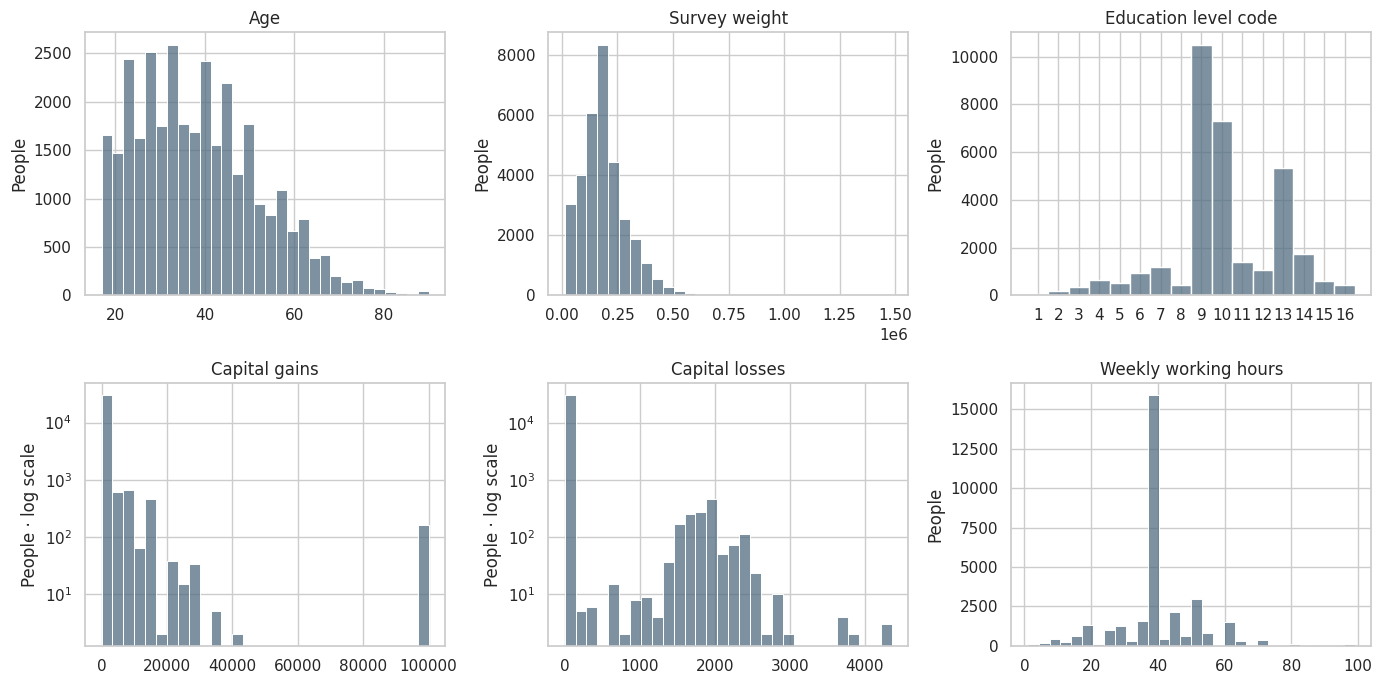

In [12]:
titles = {"age": "Age", "fnlwgt": "Survey weight", "education-num": "Education level code", "capital-gain": "Capital gains", "capital-loss": "Capital losses", "hours-per-week": "Weekly working hours"}
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for column, ax in zip(numerical, axes.flat):
    sns.histplot(data=train_df, x=column, bins=30, discrete=column == "education-num", ax=ax, color="#526D82")
    ax.set(title=titles[column], xlabel="", ylabel="People")
    if column == "education-num":
        ax.set_xticks(range(1, 17))
    if column in ["capital-gain", "capital-loss"]:
        ax.set_yscale("log")
        ax.set_ylabel("People · log scale")
plt.tight_layout()
plt.show()

In [13]:
capital_zeros = train_df[["capital-gain", "capital-loss"]].eq(0).mean().mul(100)
display(capital_zeros.to_frame("Zero values %").round(2))

,Zero values %
capital-gain,91.67
capital-loss,95.33


- **Hours:** peak around 40.
- **Capital:** mostly zero, with a long positive tail.
- **Charts:** logarithmic counts; recorded values unchanged.

### Categorical distributions

Change `column` to inspect another feature.

In [14]:
categorical = train_df.select_dtypes(exclude="number").columns.drop("income").tolist()
category_rows = []

for column in categorical:
    counts = train_df[column].value_counts()
    category_rows.append({
        "Column": column,
        "Categories number": len(counts),
        "Most common": counts.index[0],
        "Most common count": counts.iloc[0],
        "Most common share %": 100 * counts.iloc[0] / len(train_df),
        "Least common": counts.index[-1],
        "Least common count": counts.iloc[-1],
        "Least common share %": 100 * counts.iloc[-1] / len(train_df)
    })

display(pd.DataFrame(category_rows).set_index("Column").round(2))



,Categories number,Most common,Most common count,Most common share %,Least common,Least common count,Least common share %
Column,,,,,,,
workclass,8,Private,22696,69.70,Never-worked,7,0.02
education,16,HS-grad,10501,32.25,Preschool,51,0.16
marital-status,7,Married-civ-spouse,14976,45.99,Married-AF-spouse,23,0.07
occupation,14,Prof-specialty,4140,12.71,Armed-Forces,9,0.03
relationship,6,Husband,13193,40.52,Other-relative,981,3.01
race,5,White,27816,85.43,Other,271,0.83
sex,2,Male,21790,66.92,Female,10771,33.08
native-country,41,United-States,29170,89.59,Holand-Netherlands,1,0.00


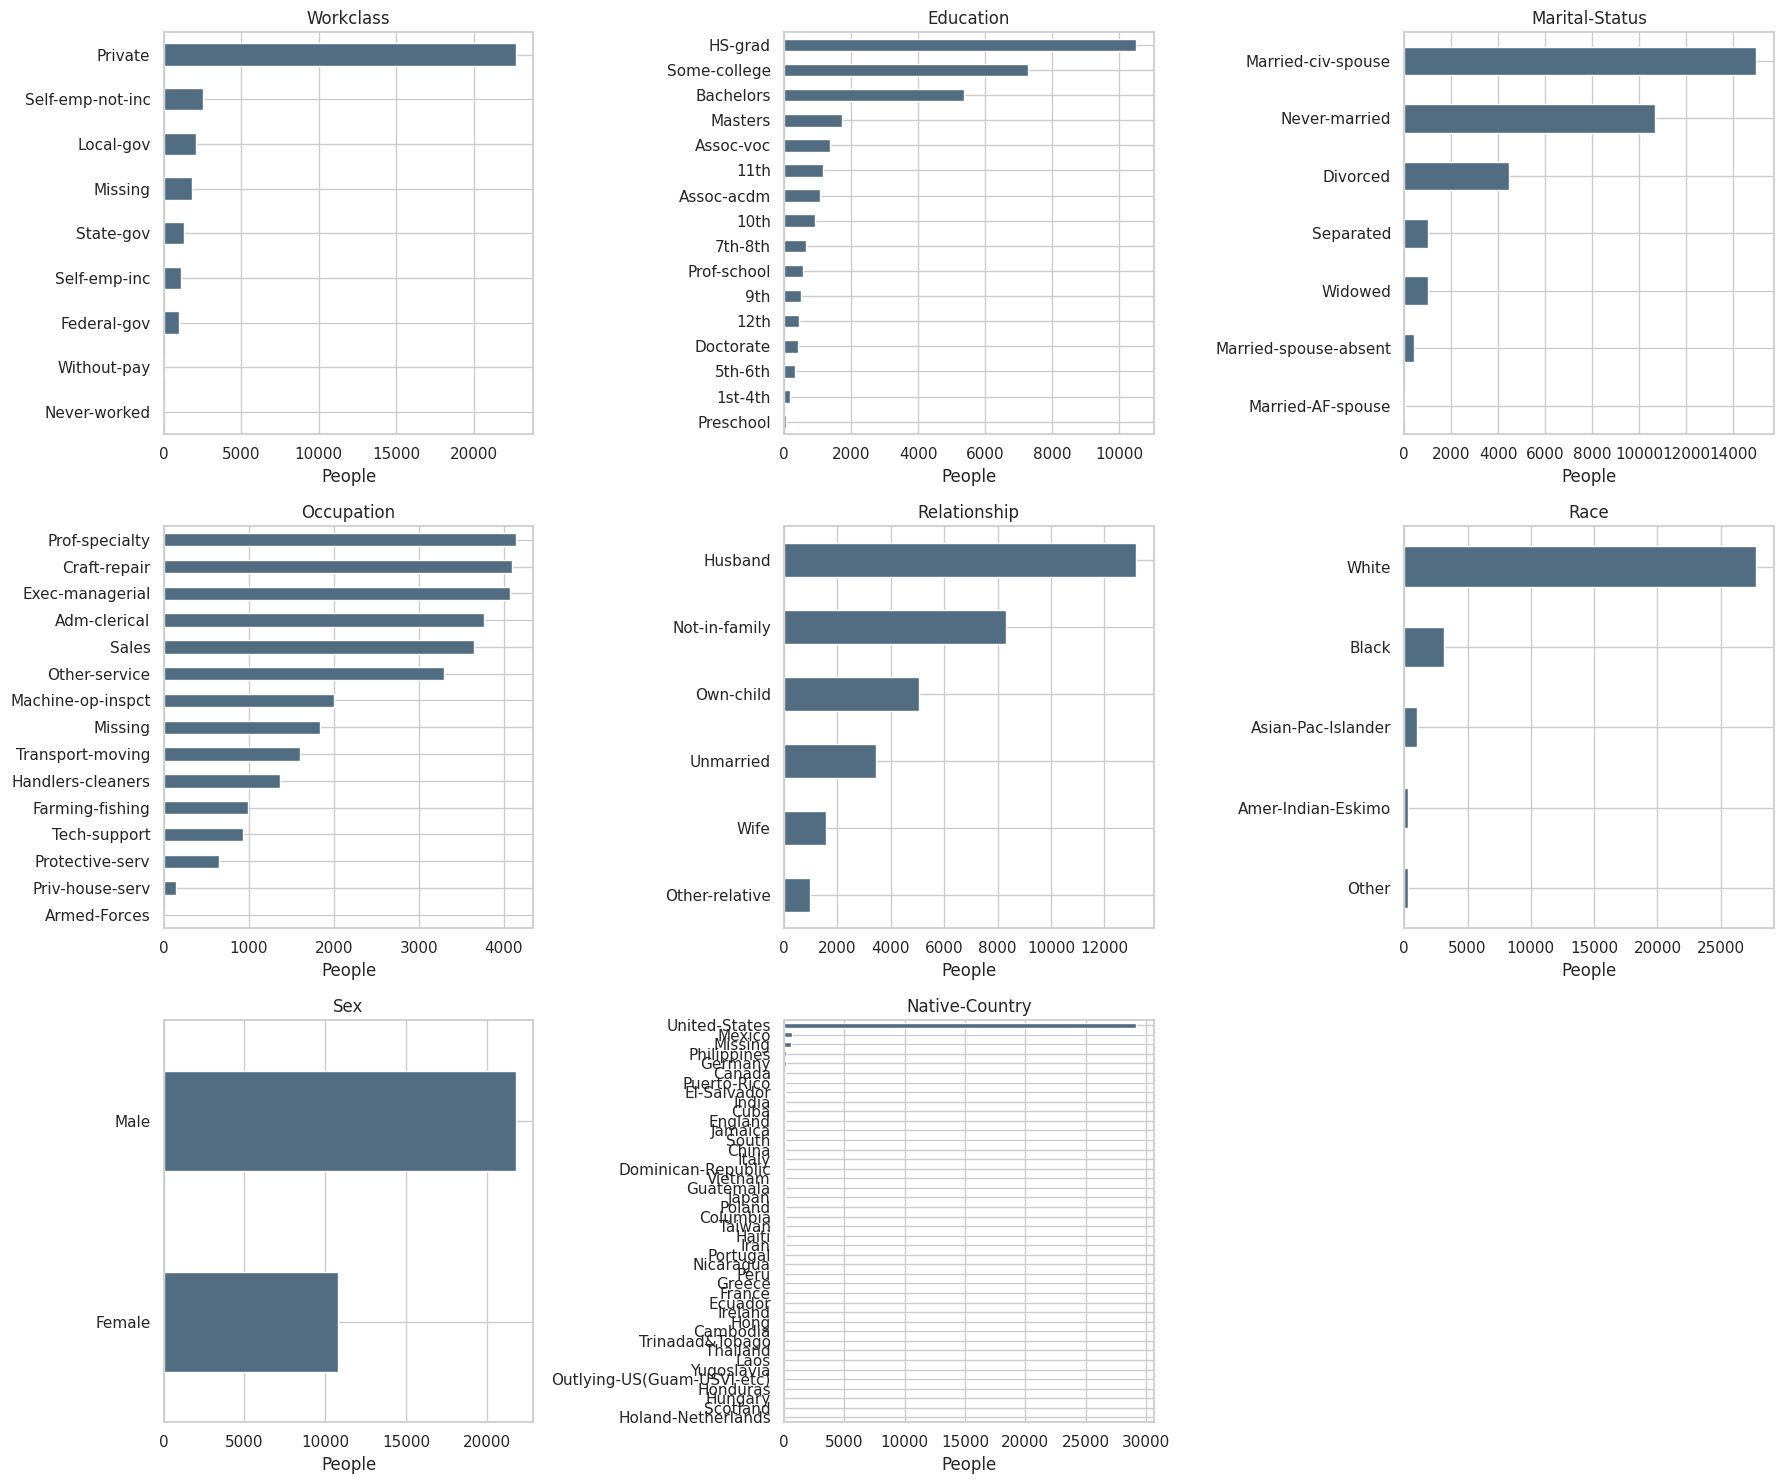

In [15]:
import math

n_cols = 3
n_rows = math.ceil(len(categorical) / n_cols)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(18, 5 * n_rows)
)

axes = axes.flatten()

for column, ax in zip(categorical, axes):
    counts = train_df[column].fillna("Missing").value_counts().sort_values()

    counts.plot.barh(ax=ax, color="#526D82")

    ax.set(
        title=column.title(),
        xlabel="People",
        ylabel=""
    )

# Remove empty plots
for ax in axes[len(categorical):]:
    ax.remove()

plt.tight_layout()
plt.show()

- **Common:** private employment, high-school education, US origin.
- **Rare:** some categories have few records.
- **Missing:** a chart label only; no values filled yet.

### Missing values

In [16]:
missing = pd.DataFrame({"Missing": train_df.isna().sum(), "Share %": 100 * train_df.isna().mean()})
display(missing.loc[missing["Missing"].gt(0)].sort_values("Missing", ascending=False).round(2))

,Missing,Share %
occupation,1843,5.66
workclass,1836,5.64
native-country,583,1.79


**Missing values:** categorical only.

### Repeated rows and consistency

In [17]:
checks = pd.Series({
    "Repeated training rows": train_df.duplicated().sum(),
    "Age below 17": train_df["age"].lt(17).sum(),
    "Nonpositive working hours": train_df["hours-per-week"].le(0).sum(),
    "Negative capital values": train_df[["capital-gain", "capital-loss"]].lt(0).sum().sum(),
    "Nonpositive survey weights": train_df["fnlwgt"].le(0).sum(),
    "Education codes outside 1–16": (~train_df["education-num"].between(1, 16)).sum(),
    "Missing income labels": train_df["income"].isna().sum(),
    "Unexpected income labels": (~train_df["income"].isin(["<=50K", ">50K"])).sum(),
    "Education labels with multiple codes": train_df.groupby("education")["education-num"].nunique().gt(1).sum(),
    "Education codes with multiple labels": train_df.groupby("education-num")["education"].nunique().gt(1).sum()
}, name="Cases")
display(checks.to_frame())
feature_columns = columns[:-1]
overlap = test_df.merge(train_df[feature_columns].drop_duplicates(), on=feature_columns, how="inner")
print("Test records with features matching training records:", len(overlap))

,Cases
Repeated training rows,24
Age below 17,0
Nonpositive working hours,0
Negative capital values,0
Nonpositive survey weights,0
Education codes outside 1–16,0
Missing income labels,0
Unexpected income labels,0
Education labels with multiple codes,0
Education codes with multiple labels,0


Test records with features matching training records: 26


- Numerical and income-label checks pass.
- Education labels and codes correspond one-to-one.
- Repeated records and matches across sets are present.

### Unusual numerical values

Boxplots and the interquartile rule flag values for review. A flag does not prove an error.

,Lower limit,Upper limit,Flagged records
Column,,,
age,-2.0,78.0,143
hours-per-week,32.5,52.5,9008


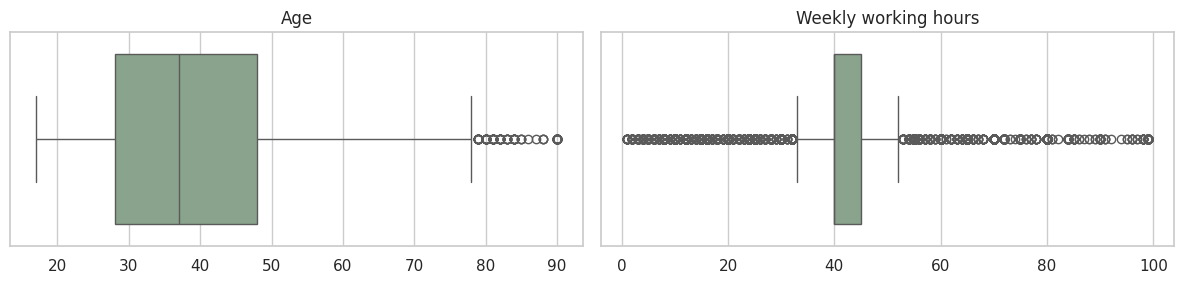

In [18]:
outlier_rows = []
for column in ["age", "hours-per-week"]:
    q1 = train_df[column].quantile(.25)
    q3 = train_df[column].quantile(.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    flagged = ~train_df[column].between(lower, upper)
    outlier_rows.append({"Column": column, "Lower limit": lower, "Upper limit": upper, "Flagged records": flagged.sum()})
display(pd.DataFrame(outlier_rows).set_index("Column"))

fig, axes = plt.subplots(1, 2, figsize=(12, 3))
for column, ax in zip(["age", "hours-per-week"], axes):
    sns.boxplot(data=train_df, x=column, ax=ax, color="#86A789")
    ax.set(title=titles[column], xlabel="")
plt.tight_layout()
plt.show()

- Older ages, part-time work and long working weeks can be valid.
- Capital quartiles are both zero: the rule would flag every positive amount.

### Relationships with income

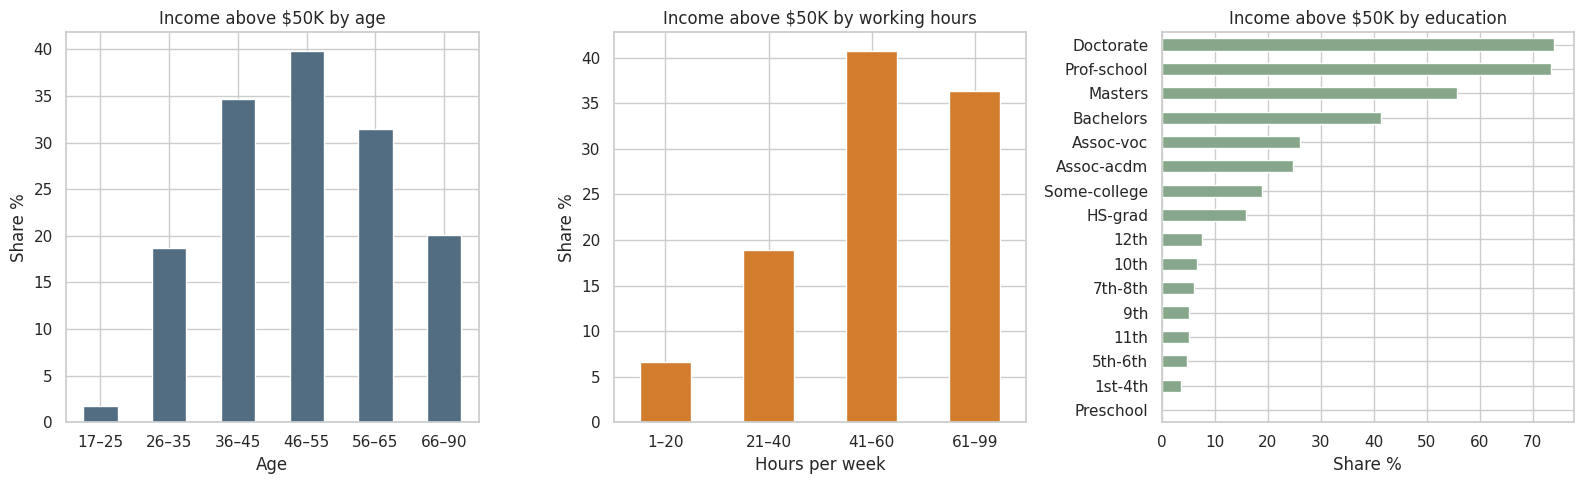

In [19]:
high_income = train_df["income"].eq(">50K")
age_groups = pd.cut(train_df["age"], [16, 25, 35, 45, 55, 65, 90], labels=["17–25", "26–35", "36–45", "46–55", "56–65", "66–90"])
hour_groups = pd.cut(train_df["hours-per-week"], [0, 20, 40, 60, 99], labels=["1–20", "21–40", "41–60", "61–99"])
age_rates = high_income.groupby(age_groups, observed=True).mean().mul(100)
hour_rates = high_income.groupby(hour_groups, observed=True).mean().mul(100)
education_rates = high_income.groupby(train_df["education"]).mean().mul(100)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
age_rates.plot.bar(ax=axes[0], color="#526D82", rot=0)
hour_rates.plot.bar(ax=axes[1], color="#D27D2D", rot=0)
education_rates.sort_values().plot.barh(ax=axes[2], color="#86A789")
axes[0].set(title="Income above $50K by age", xlabel="Age", ylabel="Share %")
axes[1].set(title="Income above $50K by working hours", xlabel="Hours per week", ylabel="Share %")
axes[2].set(title="Income above $50K by education", xlabel="Share %", ylabel="")
plt.tight_layout()
plt.show()

| Variable | Observed income pattern |
|---|---|
| Education | Higher levels have higher-income shares |
| Working hours | Above 40 hours has a higher-income share |
| Age | Share peaks in middle age |

### Numerical relationships

Spearman correlation compares ranks, including ordered education codes.

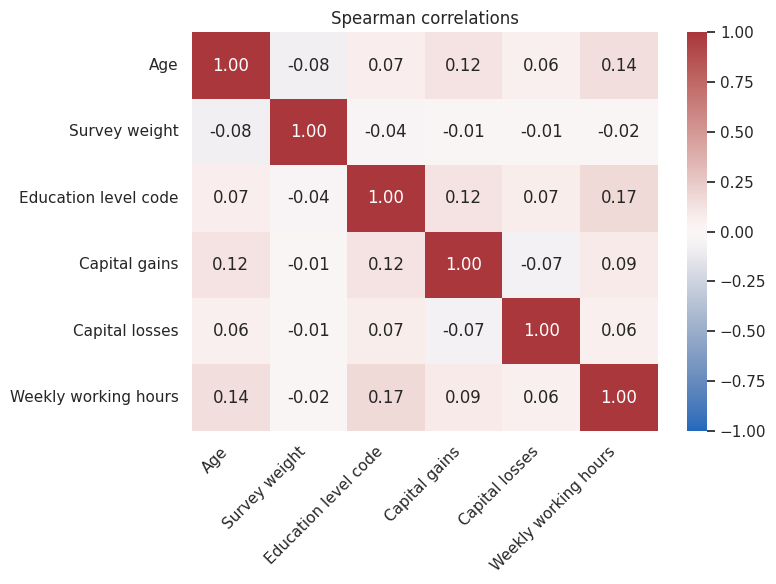

In [20]:
correlation = train_df[numerical].corr(method="spearman")
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(correlation, annot=True, fmt=".2f", vmin=-1, vmax=1, center=0, cmap="vlag", ax=ax)
ax.set(title="Spearman correlations", xlabel="", ylabel="")
ax.set_xticklabels([titles[column] for column in numerical], rotation=45, ha="right")
ax.set_yticklabels([titles[column] for column in numerical], rotation=0)
plt.tight_layout()
plt.show()

**Weak pairwise correlations:** combinations of variables may still matter.

### Preparation decisions

| Finding | Action | Reason |
|---|---|---|
| Missing categories | Fill with `Unknown` | Keep records and missingness visible |
| Repeated and cross-set matches | Retain; check test sensitivity later | No person identifier |
| Extreme ages and hours | Retain | Plausible values; no proven error |
| Capital's long positive tail | Add `log1p` features | Compress large values; preserve zero |
| Duplicate education information | Use `education-num` | Avoid redundant inputs |
| `fnlwgt` | Keep in data; exclude from models | Survey weight, not a personal attribute |
| Rare categories | Retain; accept unseen categories | Preserve records and allow new categories |
| Race and sex | Keep for audit; exclude from models | Compare groups; other features can remain proxies |
| Unequal income classes | Stratified validation; precision, recall, F1, average precision | Assess the smaller class |

## 4. Data Preparation

### Missing values

Work on copies of the loaded data.

In [21]:
clean_train = train_df.copy()
clean_test = test_df.copy()

for data in [clean_train, clean_test]:
    for column in categorical:
        data[column] = data[column].fillna("Unknown")

### Capital features

`log1p(x) = log(1 + x)`. Zero remains zero; original amounts are retained.

In [22]:
for data in [clean_train, clean_test]:
    data["capital-gain-log"] = np.log1p(data["capital-gain"])
    data["capital-loss-log"] = np.log1p(data["capital-loss"])

display(clean_train[["capital-gain", "capital-gain-log", "capital-loss", "capital-loss-log"]].head())

,capital-gain,capital-gain-log,capital-loss,capital-loss-log
0,2174,7.684784,0,0.0
1,0,0.000000,0,0.0
2,0,0.000000,0,0.0
3,0,0.000000,0,0.0
4,0,0.000000,0,0.0


### Verification

Check: all rows retained, no missing values, unchanged targets, finite numbers.

In [23]:
summary = pd.DataFrame({"Rows": [len(clean_train), len(clean_test)], "Columns": [clean_train.shape[1], clean_test.shape[1]], "Missing values": [clean_train.isna().sum().sum(), clean_test.isna().sum().sum()]}, index=["Training", "Test"])
display(summary)
assert len(clean_train) == len(train_df)
assert len(clean_test) == len(test_df)
assert clean_train["income"].equals(train_df["income"])
assert clean_test["income"].equals(test_df["income"])
assert clean_train.isna().sum().sum() == 0
assert clean_test.isna().sum().sum() == 0
assert np.isfinite(clean_train.select_dtypes(include="number")).all().all()
assert np.isfinite(clean_test.select_dtypes(include="number")).all().all()

,Rows,Columns,Missing values
Training,32561,17,0
Test,16281,17,0


### Inputs for segmentation and classification

| Task | Inputs | Target |
|---|---|---|
| Segmentation | Age, education code, working hours | None |
| Classification | Selected features + logged capital values | `0`: `<=50K`; `1`: `>50K` |

Equal spacing between education codes is an approximation.

In [24]:
segmentation_df = clean_train[["age", "education-num", "hours-per-week"]].copy()

excluded = ["income", "education", "fnlwgt", "race", "sex", "capital-gain", "capital-loss"]
X_train = clean_train.drop(columns=excluded).copy()
X_test = clean_test.drop(columns=excluded).copy()
y_train = clean_train["income"].eq(">50K").astype(int)
y_test = clean_test["income"].eq(">50K").astype(int)

print("Segmentation inputs:", segmentation_df.columns.tolist())
print("Classification inputs:", X_train.columns.tolist())
print("Matching classification columns:", X_train.columns.equals(X_test.columns))

Segmentation inputs: ['age', 'education-num', 'hours-per-week']
Classification inputs: ['age', 'workclass', 'education-num', 'marital-status', 'occupation', 'relationship', 'hours-per-week', 'native-country', 'capital-gain-log', 'capital-loss-log']
Matching classification columns: True


### Encoding and scaling

| Transform | Purpose |
|---|---|
| Standardization | Comparable numerical scales |
| One-hot encoding | Binary category columns; accept unseen categories |

- **Classification:** fit inside each training fold through a pipeline.
- **Clustering:** fit the scaler on segmentation inputs.

The objects below are not fitted yet.

In [25]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numeric_inputs = X_train.select_dtypes(include="number").columns.tolist()
category_inputs = X_train.select_dtypes(exclude="number").columns.tolist()

classification_preparation = ColumnTransformer([
    ("numerical", StandardScaler(), numeric_inputs),
    ("categorical", OneHotEncoder(handle_unknown="ignore"), category_inputs)
])
segmentation_preparation = StandardScaler()

display(pd.DataFrame({"Preparation": ["Standardization", "One-hot encoding"], "Columns": [", ".join(numeric_inputs), ", ".join(category_inputs)]}))

,Preparation,Columns
0,Standardization,"age, education-num, hours-per-week, capital-ga..."
1,One-hot encoding,"workclass, marital-status, occupation, relatio..."
